# AI Technical Support Assistant - KPI Dashboard

## Project Objective

This notebook focuses on operational analytics and KPI tracking for customer support workflows. The objective is to analyze ticket resolution performance, escalation trends, customer satisfaction, and support efficiency metrics using the processed support ticket dataset.

The dashboard layer complements the AI retrieval assistant by providing operational insights into customer support performance and workflow behavior.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
support_df = pd.read_csv(r"C:\Users\VAIBHAV\customer_support_tickets.csv")
support_df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [5]:
support_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

# Datetime Conversion and KPI Preparation

Operational timestamp columns were converted into datetime format to support temporal analysis and workflow timing insights.

The following columns were converted:
- Date of Purchase
- First Response Time
- Time to Resolution

This step was necessary to enable time-based KPI analysis and operational activity tracking.

In [20]:
support_df['Date of Purchase'] = pd.to_datetime(
    support_df['Date of Purchase'],
    errors='coerce'
)

support_df['First Response Time'] = pd.to_datetime(
    support_df['First Response Time'],
    errors='coerce'
)

support_df['Time to Resolution'] = pd.to_datetime(
    support_df['Time to Resolution'],
    errors='coerce'
)

support_df['Customer Satisfaction Rating'] = pd.to_numeric(
    support_df['Customer Satisfaction Rating'],
    errors='coerce'
)

support_df['First Response Hours'] = (
    support_df['First Response Time'] - support_df['Date of Purchase']
).dt.total_seconds() / 3600

support_df['Resolution Hours'] = (
    support_df['Time to Resolution'] - support_df['Date of Purchase']
).dt.total_seconds() / 3600

support_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   object        
 2   Customer Email                8469 non-null   object        
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   object        
 5   Product Purchased             8469 non-null   object        
 6   Date of Purchase              8469 non-null   datetime64[ns]
 7   Ticket Type                   8469 non-null   object        
 8   Ticket Subject                8469 non-null   object        
 9   Ticket Description            8469 non-null   object        
 10  Ticket Status                 8469 non-null   object        
 11  Resolution                    

In [21]:
support_df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
First Response Hours            2819
Resolution Hours                5700
dtype: int64

In [22]:
support_df[support_df.isnull().any(axis=1)]

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,First Response Hours,Resolution Hours
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN,19236.260000,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN,17776.760556,NaN
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,Open,NaN,Low,Social media,NaT,NaT,NaN,NaN,NaN
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,Open,NaN,Critical,Social media,NaT,NaT,NaN,NaN,NaN
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09,Refund request,Battery life,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Social media,NaT,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8462,8463,Shelby Douglas,rhendrix@example.net,49,Female,Samsung Soundbar,2020-10-21,Refund request,Display issue,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Email,2023-06-02 00:36:18,NaT,NaN,22896.605000,NaN
8463,8464,Brandon Walsh,michele06@example.net,54,Other,LG Washing Machine,2021-08-29,Billing inquiry,Data loss,There seems to be a glitch in the {product_pur...,Open,NaN,Medium,Email,NaT,NaT,NaN,NaN,NaN
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaT,NaT,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaT,NaT,NaN,NaN,NaN


# Subset DataFrame Creation

Separate subset DataFrames were created to support focused KPI analysis workflows.

The subsets included:
- resolved_df → resolved tickets for resolution analysis
- rating_df → tickets containing customer satisfaction ratings
- open_tickets → unresolved or pending support tickets

This modular workflow structure improves analytical clarity and allows KPI calculations to be performed on relevant operational records only.

In [23]:
resolved_df = support_df.dropna(
    subset=['Time to Resolution']
)
rating_df = support_df.dropna(
    subset=['Customer Satisfaction Rating']
)
open_tickets = support_df[
    support_df['Resolution'].isnull()
]

# Ticket Status Analysis

Ticket status distribution analysis was performed to evaluate overall support workflow behavior and ticket lifecycle distribution.

In [24]:
support_df['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

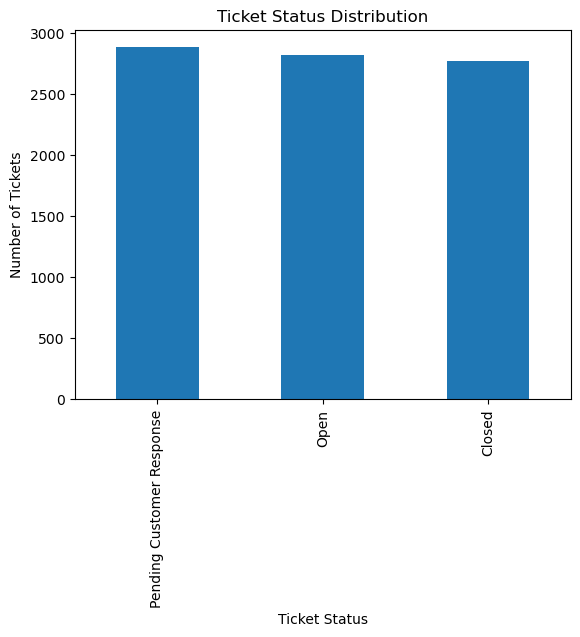

In [25]:
support_df['Ticket Status'].value_counts().plot(
    kind='bar'
)

plt.title('Ticket Status Distribution')

plt.xlabel('Ticket Status')

plt.ylabel('Number of Tickets')

plt.show()

# Ticket Priority Analysis

Ticket priority distribution analysis was conducted to understand the proportion of low, medium, high, and critical support issues.

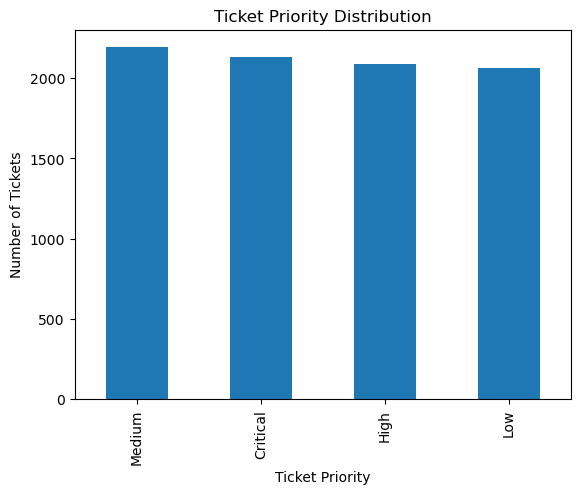

In [26]:
support_df['Ticket Priority'].value_counts().plot(
    kind='bar'
)

plt.title('Ticket Priority Distribution')

plt.xlabel('Ticket Priority')

plt.ylabel('Number of Tickets')

plt.show()

# Ticket Channel Analysis

Ticket channel analysis was performed to evaluate how customers interact with the support system across different communication channels.

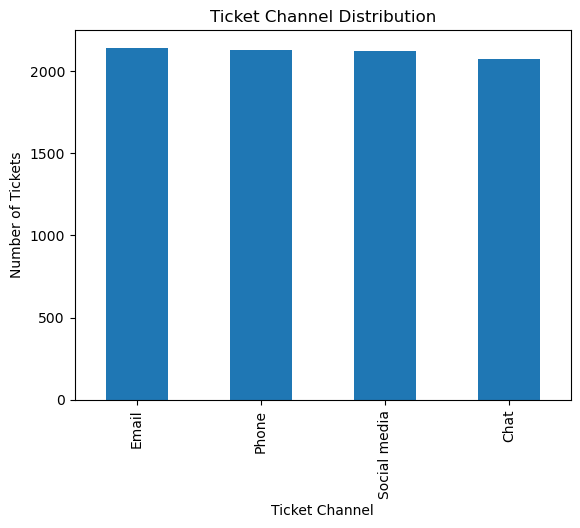

In [27]:
support_df['Ticket Channel'].value_counts().plot(
    kind='bar'
)

plt.title('Ticket Channel Distribution')

plt.xlabel('Ticket Channel')

plt.ylabel('Number of Tickets')

plt.show()

# Resolution Time Investigation

Initial attempts were made to calculate resolution duration metrics using ticket timestamps. During investigation, it was identified that the dataset primarily contained timestamp-based workflow information rather than direct duration metrics.

Further analysis showed that:
- First Response Time and Time to Resolution were already stored as timestamp values
- Date of Purchase represented a separate business event rather than ticket creation time

As a result, the dashboard approach was adjusted to focus on:
- temporal activity analysis
- response timing patterns
- ticket resolution timing trends

instead of direct SLA duration calculations.

In [28]:
resolved_df['Time to Resolution'].describe()

count                             2769
mean     2023-06-01 11:17:21.509931520
min                2023-05-31 21:53:30
25%                2023-06-01 05:34:43
50%                2023-06-01 11:17:48
75%                2023-06-01 17:07:32
max                2023-06-02 00:55:33
Name: Time to Resolution, dtype: object

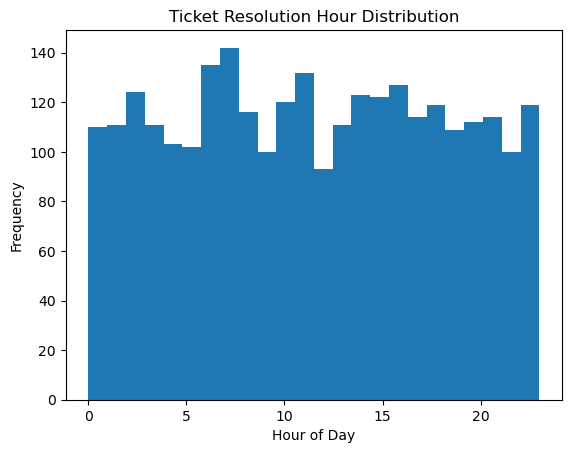

In [32]:
support_df['Time to Resolution'].dropna().dt.hour.plot(
    kind='hist',
    bins=24
)

plt.title('Ticket Resolution Hour Distribution')

plt.xlabel('Hour of Day')

plt.show()

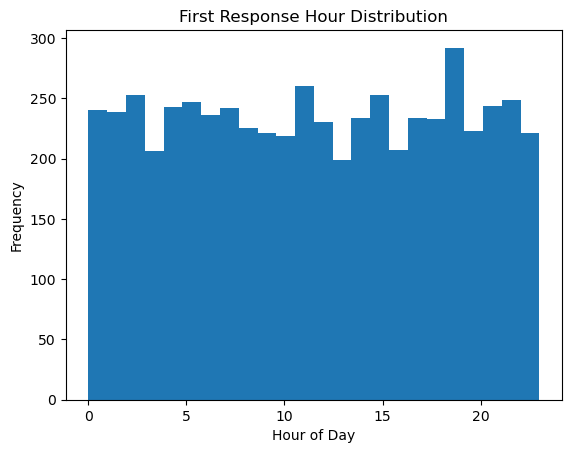

In [33]:
support_df['First Response Time'].dropna().dt.hour.plot(
    kind='hist',
    bins=24
)

plt.title('First Response Hour Distribution')

plt.xlabel('Hour of Day')

plt.show()

## Impact of higher-priority tickets on customer satisfaction

In [34]:
rating_df.groupby(
    'Ticket Priority'
)['Customer Satisfaction Rating'].mean()

Ticket Priority
Critical    2.958678
High        2.982979
Low         3.052795
Medium      2.976945
Name: Customer Satisfaction Rating, dtype: float64

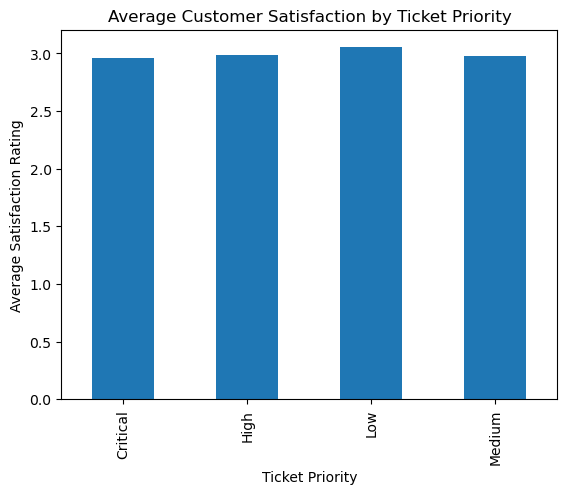

In [35]:
rating_df.groupby(
    'Ticket Priority'
)['Customer Satisfaction Rating'].mean().plot(
    kind='bar'
)

plt.title('Average Customer Satisfaction by Ticket Priority')

plt.xlabel('Ticket Priority')

plt.ylabel('Average Satisfaction Rating')

plt.show()

## Impact of ticket workflow status on customer satisfaction

In [36]:
rating_df.groupby(
    'Ticket Status'
)['Customer Satisfaction Rating'].mean()

Ticket Status
Closed    2.991333
Name: Customer Satisfaction Rating, dtype: float64

## Most often unresolved ticket priorities

In [37]:
support_df.groupby(
    'Ticket Priority'
)['Resolution'].apply(
    lambda x: x.isnull().sum()
)

Ticket Priority
Critical    1403
High        1380
Low         1419
Medium      1498
Name: Resolution, dtype: int64

### Higher-priority tickets showed slightly lower customer satisfaction ratings, indicating that urgent or complex support issues may negatively impact customer experience and resolution perception.